In [1]:
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import deeptime
import ot

In [5]:
T = 10000
x = np.zeros(T)
x[:T//2] = 0.85 * np.random.randn(T//2)
x[T // 2:] = 0.75 * np.random.randn(T // 2) + 1
x = np.reshape(x, (-1,1))
w = 100
dists = [np.sqrt(ot.emd2_1d(x[t-w:t],x[t:t+w])) for t in range(w, T-w)]

In [6]:
d = np.concatenate((np.zeros(w), np.array(dists), np.zeros(w)))

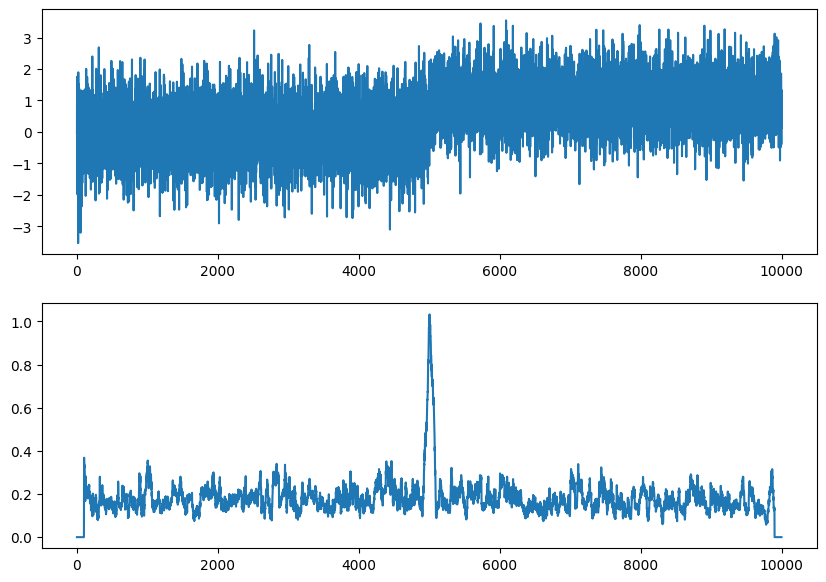

In [9]:
fig, ax = plt.subplots(2,1, figsize=(10,7))

sns.lineplot(x, ax=ax[0], legend=False)
sns.lineplot(d, ax=ax[1])
#np.argmax(dists) + w
#ax[0].set_title("Trajectory")
#ax[1].set_title("Approximated Metric Wasserstein Derivative")
ax[0]
plt.savefig("cp-concept.pdf", bbox_inches="tight")
